# Feature Scaling 

### Standardization

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
# load the dataset
df = pd.read_csv("DATASET/Social_Network_Ads.csv")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [4]:
# split the dataset 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(df.drop('Purchased',axis =1),
                                                df['Purchased'],test_size=0.3,
                                               random_state =0)

In [5]:
print(X_train.shape,X_test.shape)

(280, 2) (120, 2)


In [6]:
# standard scalar
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()
# fit the traing set
sc.fit(X_train)

# transform the test and train set
X_train_sc =sc.transform(X_train)
X_test_sc  =sc.transform(X_test)

print(sc.mean_)


[3.78642857e+01 6.98071429e+04]


In [7]:
print(X_train)

     Age  EstimatedSalary
92    26            15000
223   60           102000
234   38           112000
232   40           107000
377   42            53000
..   ...              ...
323   48            30000
192   29            43000
117   36            52000
47    27            54000
172   26           118000

[280 rows x 2 columns]


In [8]:
print(X_train_sc)

[[-1.1631724  -1.5849703 ]
 [ 2.17018137  0.93098672]
 [ 0.0133054   1.22017719]
 [ 0.20938504  1.07558195]
 [ 0.40546467 -0.48604654]
 [-0.28081405 -0.31253226]
 [ 0.99370357 -0.8330751 ]
 [ 0.99370357  1.8563962 ]
 [ 0.0133054   1.24909623]
 [-0.86905295  2.26126285]
 [-1.1631724  -1.5849703 ]
 [ 2.17018137 -0.80415605]
 [-1.35925203 -1.46929411]
 [ 0.40546467  2.2901819 ]
 [ 0.79762394  0.75747245]
 [-0.96709276 -0.31253226]
 [ 0.11134522  0.75747245]
 [-0.96709276  0.55503912]
 [ 0.30742485  0.06341534]
 [ 0.69958412 -1.26686079]
 [-0.47689368 -0.0233418 ]
 [-1.7514113   0.3526058 ]
 [-0.67297331  0.12125343]
 [ 0.40546467  0.29476771]
 [-0.28081405  0.06341534]
 [-0.47689368  2.2901819 ]
 [ 0.20938504  0.03449629]
 [ 1.28782302  2.20342476]
 [ 0.79762394  0.26584866]
 [-0.28081405  0.15017248]
 [ 0.0133054  -0.54388463]
 [-0.18277423  0.15017248]
 [-0.08473441  0.23692961]
 [ 0.0133054  -0.25469417]
 [ 2.17018137  1.104501  ]
 [-1.7514113   0.3526058 ]
 [ 1.87606192  0.12125343]
 

In [9]:
# save our scaled output in cloumn
X_train_sc =pd.DataFrame(X_train_sc,columns=X_train.columns)
X_test_sc  =pd.DataFrame(X_test_sc,columns=X_test.columns)

In [10]:
np.round(X_train.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,38.0,69807.0
std,10.0,34641.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [11]:
np.round(X_train_sc.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


Text(0.5, 1.0, 'After Scaling')

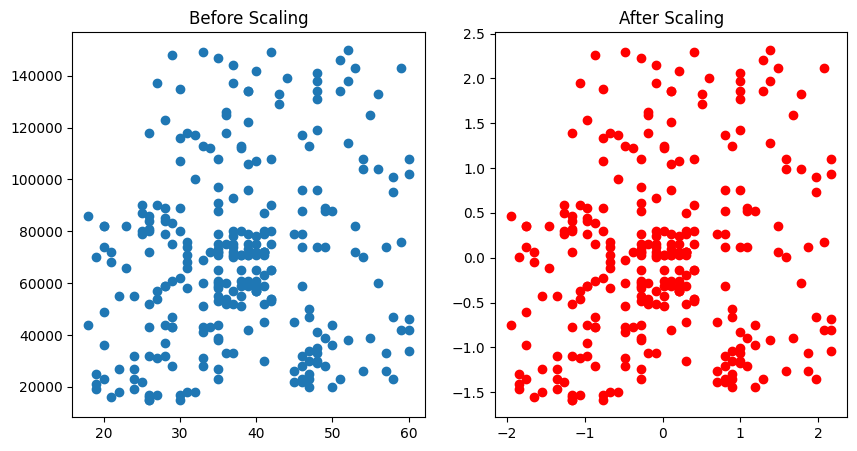

In [12]:
# Effect of scaling 
# plot two subplot for before and after scaling 

fig ,(axis1,axis2) =plt.subplots(ncols =2,figsize =(10,5))
axis1.scatter(X_train['Age'],X_train['EstimatedSalary'])
axis1.set_title("Before Scaling")
axis2.scatter(X_train_sc['Age'],X_train_sc['EstimatedSalary'],color ='red')
axis2.set_title("After Scaling")

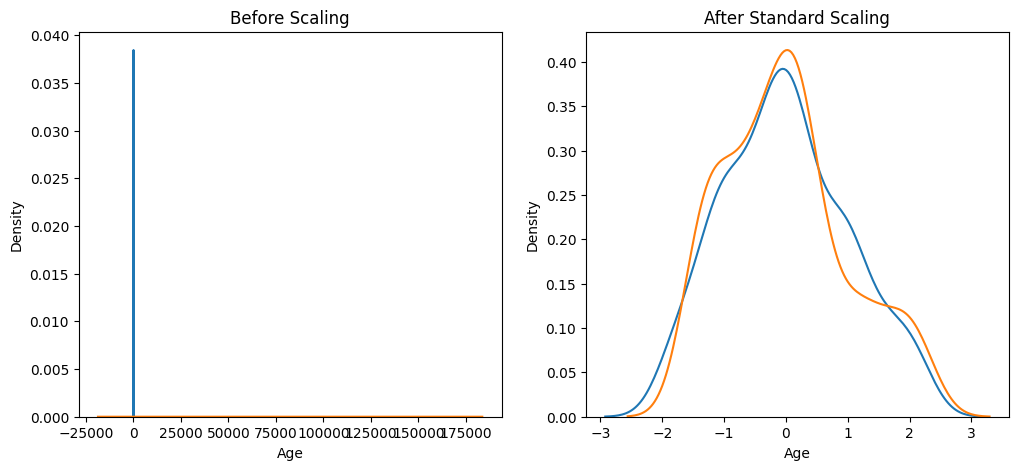

In [13]:
## draw a kde plot 
fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
axis1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=axis1)
sns.kdeplot(X_train['EstimatedSalary'], ax=axis1)

# after scaling
axis2.set_title('After Standard Scaling')
sns.kdeplot(X_train_sc['Age'], ax=axis2)
sns.kdeplot(X_train_sc['EstimatedSalary'], ax=axis2)
plt.show()

<Axes: title={'center': 'Age distribution after scaling'}, xlabel='Age', ylabel='Density'>

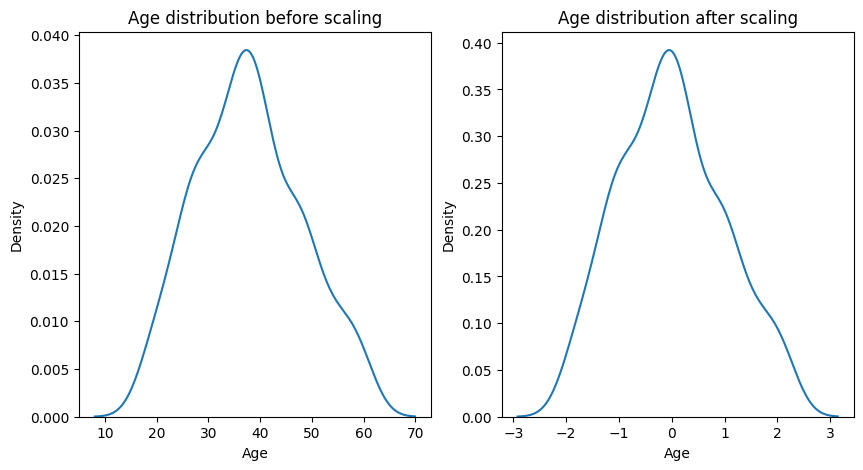

In [14]:
# comparision of distribution
fig ,(axis1,axis2)=plt.subplots(ncols =2,figsize=(10,5))
# before scaling 
axis1.set_title('Age distribution before scaling')
sns.kdeplot(X_train['Age'],ax =axis1)

# after scaling
axis2.set_title('Age distribution after scaling')
sns.kdeplot(X_train_sc['Age'],ax =axis2)

In [ ]:
# similarly for another feature 
fig ,(axis1,axis2)=plt.subplots(ncols =2,figsize=(10,5))
# before scaling 
axis1.set_title('salary distribution before scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax =axis1)

# after scaling
axis2.set_title('salary distribution after scaling')
sns.kdeplot(X_train_sc['EstimatedSalary'],ax =axis2)

In [ ]:
# IMPORTANCE OF SCALING 

# train a simple classification model
from sklearn.linear_model import LogisticRegression
# create a two object of the model 
model =LogisticRegression()
model_sc=LogisticRegression()

# fit both
model.fit(X_train,y_train)
model_sc.fit(X_train_sc,y_train)

# predict the out put 
y_pred =model.predict(X_test)
y_pred_sc =model_sc.predict(X_test_sc)

#calulate the actual accuracy
from sklearn.metrics import accuracy_score
print("not scaled",accuracy_score(y_test,y_pred))
print("scaled ",accuracy_score(y_test,y_pred_sc))

In [ ]:
# apply on the another model 
# decision tree

from sklearn.tree import DecisionTreeClassifier
model_dc = DecisionTreeClassifier()
model_dc_sc =DecisionTreeClassifier()

# fit both
model_dc.fit(X_train,y_train)
model_dc_sc.fit(X_train_sc,y_train)

# predict the out put 
y_pred =model_dc.predict(X_test)
y_pred_sc =model_dc_sc.predict(X_test_sc)

#calulate the actual accuracy
from sklearn.metrics import accuracy_score
print("not scaled",accuracy_score(y_test,y_pred))
print("scaled ",accuracy_score(y_test,y_pred_sc))

In [ ]:
# understanding the effect of outlier 
# append method now not included in pandas
# add outlier to existing dataframe
import pandas as pd

# Create the new data as a DataFrame
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [100, 2500000, 3500000],
    'Purchased': [0, 1, 1]
})

# Combine the original df and new_data along rows
df = pd.concat([df, new_data], ignore_index=True)


In [ ]:
df

In [ ]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [ ]:
# again split the data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(df.drop('Purchased',axis =1),
                                                df['Purchased'],test_size=0.3,
                                               random_state =0)
# standard scalar
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()
# fit the traing set
sc.fit(X_train)

# transform the test and train set
X_train_sc =sc.transform(X_train)
X_test_sc  =sc.transform(X_test)

print(sc.mean_)


fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(10, 5))

# Before Scaling (Uses DataFrame string names)
axis1.scatter(X_train['Age'], X_train['EstimatedSalary'])
axis1.set_title("Before Scaling")

# After Scaling (Uses NumPy integer indexing: column 0 and column 1)
axis2.scatter(X_train_sc[:, 0], X_train_sc[:, 1], color='red')
axis2.set_title("After Scaling")

plt.show()


#### from sctrach implementation of Standard Scalar class

In [ ]:
import numpy as np

class StandardScaler_my:

    def __init__(self):
        self.mean_ =None
        self.scale_ =None
        

    def fit(self,X):
        self.mean_=np.mean(X,axis=0)
        self.scale_=np.std(X,axis=0)
        return self

        
    def transform(self,X):
        X_scaled =(X-self.mean_)/self.scale_

        return X_scaled

    def fit_transform(self,X):
        self.fit(X)
        return self.transform(X)

In [ ]:
# test your custom class 
X = np.array([
    [170,70],
    [100,20],
    [160,60]
])

# create obj of our class
scalar = StandardScaler_my()
X_scaled = scalar.fit_transform(X)
print(X_scaled)
print()

# verify its mean is 0 and Standard Deviation is 1
print('mean',np.round(np.mean(X_scaled,axis=0)))
print('standard deviation',np.round(np.std(X_scaled, axis=0)))

### Normalization

In [1]:
import  numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import  seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv("DATASET/winequality-red.csv",usecols=[0,1,2])
df.columns =['fixed acidity','residual sugar','alcohol']
df

,fixed acidity,residual sugar,alcohol
0,7.4,0.700,0.00
1,7.8,0.880,0.00
2,7.8,0.760,0.04
3,11.2,0.280,0.56
4,7.4,0.700,0.00
...,...,...,...
1594,6.2,0.600,0.08
1595,5.9,0.550,0.10
1596,6.3,0.510,0.13
1597,5.9,0.645,0.12


In [3]:
# split the dataset 
from sklearn .model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(df.drop('alcohol',axis =1),
                                               df['alcohol'],test_size=0.2,random_state=42)

#### MINMAX Scaling

In [4]:
# sklearn implementation
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
scalar.fit(X_train)

# transform the test and train set 
X_train_sc =scalar.transform(X_train)
X_test_sc =scalar.transform(X_test)

# save it to dataframe
X_train_sc=pd.DataFrame(X_train_sc,columns=X_train.columns)
X_test_sc=pd.DataFrame(X_test_sc,columns=X_test.columns)

print(np.round(X_train.describe()))
print(np.round(X_test.describe()))

       fixed acidity  residual sugar
count         1279.0          1279.0
mean             8.0             1.0
std              2.0             0.0
min              5.0             0.0
25%              7.0             0.0
50%              8.0             1.0
75%              9.0             1.0
max             16.0             2.0
       fixed acidity  residual sugar
count          320.0           320.0
mean             8.0             1.0
std              2.0             0.0
min              5.0             0.0
25%              7.0             0.0
50%              8.0             1.0
75%              9.0             1.0
max             16.0             1.0


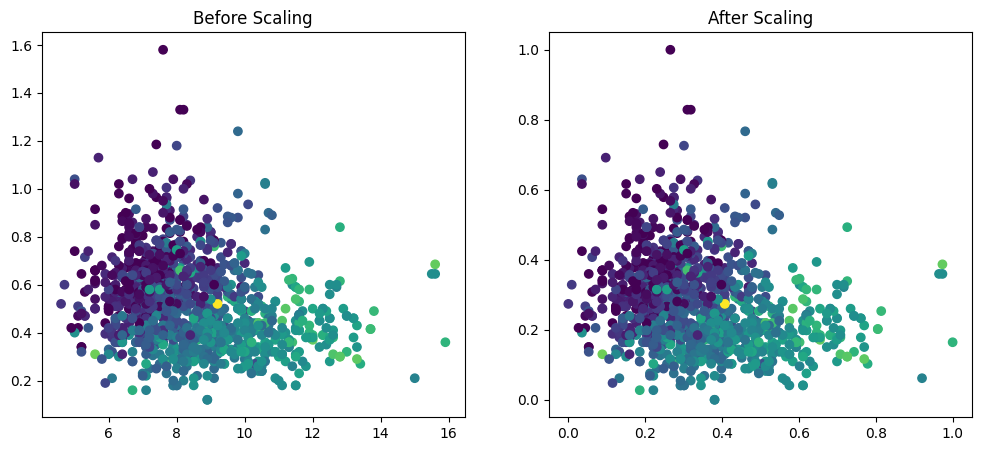

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['fixed acidity'], X_train['residual sugar'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_sc['fixed acidity'], X_train_sc['residual sugar'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

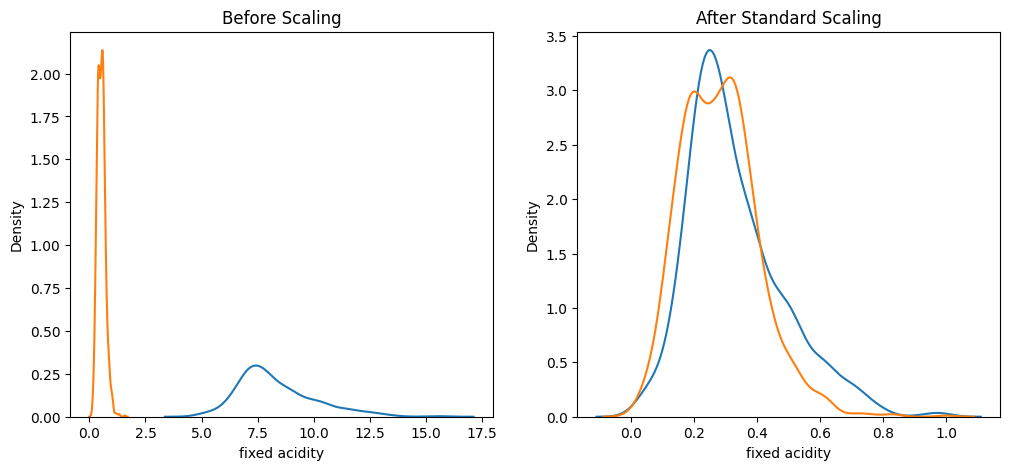

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['fixed acidity'], ax=ax1)
sns.kdeplot(X_train['residual sugar'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_sc['fixed acidity'], ax=ax2)
sns.kdeplot(X_train_sc['residual sugar'], ax=ax2)
plt.show()

#### from scratch implementation of minmax scalar

In [17]:
import numpy as np

class MinMaxScalar_my :

    def __init__(self,feature_range=(0,1)):
        self.feature_range =feature_range
        self.data_min=None
        self.data_max=None
        self.data_range =None
        

    def fit(self,X):
        #compute min
        self.data_min =np.min(X,axis =0)
        #compute max
        self.data_max= np.max(X,axis =0)
        #compute range
        self.data_range = self.data_max-self.data_min

        # handle a edge case where if both min and max equals then 
        # range becomes 0,so we have to replace 0 with 1
        self.data_range[self.data_range==0]=1

        return self

    def transform(self,X):
        # apply min max formula 
        X_std =(X - self.data_min)/self.data_range

        # set desired output range 
        # like our feature range is (0,1) then low =0 and high =1
        low ,high = self.feature_range

        return X_std*(high -low )+low

    def fit_transform(self,X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self,X):
        # Recover original feature_range
        low, high = self.feature_range

        # Convert scaled values back into [0,1]
        X_std = (X - low) / (high - low)

        # Reverse the Min-Max formula
        #
        # original = scaled * range + minimum
        return X_std * self.data_range_ + self.data_min_

In [19]:
# test your class 
X = np.array([
    [150],
    [170],
    [190]
])

# create an object of your class
sc =MinMaxScalar_my()
sc.fit(X)
sc.transform(X)

array([[0. ],
       [0.5],
       [1. ]])

In [22]:
 
X = np.array([
    [150],
    [170],
    [190]
])
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaler.fit_transform(X)

array([[0. ],
       [0.5],
       [1. ]])

#### Mean normalization Scaling

In [26]:
# from sctrach implementation
import numpy as np


class MNS:

    def __init__(self):
        self.mean = None
        self.data_min =None
        self.data_max =None
        self.data_range =None

    def fit(self,X):
        self.mean =np.mean(X,axis=0)
        self.data_min =np.min(X,axis =0)
        self.data_max= np.max(X,axis =0)
        self.data_range = self.data_max - self.data_min
        self.data_range[self.data_range == 0] = 1

        return self

    def transform(self,X):
        return (X -self.mean)/self.data_range

#### MaxAbsolute Scaling

In [32]:
import numpy as np

class MaxAbsScalar_my :
    def __init__(self,X):
        self.max_abs =None

    def fit(self,X):
        self.max_abs =np.max(np.abs(X),axis=0)
        self.max_abs[self.max_abs == 0]=1
        return self

    def transform(self,X):
        return X / self.max_abs

In [ ]:
# sklearn implementation
X = np.array([
    [150],
    [170],
    [190]
])

from sklearn.preprocessing import MaxAbsScaler
m = MaxAbsScalar(X)
m.fit(X)
m.transform(X)


#### Robust scalar

In [36]:
import numpy as np


class RobustScaler:

    def __init__(self):
        self.median_ = None
        self.iqr_ = None

    def fit(self, X):

        self.median_ = np.median(X, axis=0)

        q1 = np.percentile(X, 25, axis=0)

        q3 = np.percentile(X, 75, axis=0)

        self.iqr_ = q3 - q1

        self.iqr_[self.iqr_ == 0] = 1

        return self

    def transform(self, X):

        return (X - self.median_) / self.iqr_

    def fit_transform(self, X):

        self.fit(X)

        return self.transform(X)

    def inverse_transform(self, X):

        return X * self.iqr_ + self.median_

In [37]:
# sklearn implementation
X = np.array([
    [150],
    [170],
    [190]
])


from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit_transform(X)


array([[-1.],
       [ 0.],
       [ 1.]])